# Variational Autoencoder (VAE)

_[based on our assignment from YSDA [DeepCVG course](https://github.com/yandexdataschool/deep_vision_and_graphics/tree/fall23); materials by Victor Yurchenko]_

**TL;DR this task** will walk involve you implementing your variational autoencoder with normal latent variables - just the basic variety - to model celebrity faces from CelebA dataset.

![img](https://miro.medium.com/v2/resize:fit:1400/0*39kjKwCtVjhrvsQ7.png)


Source links (in addition to our materials):
* Original paper http://arxiv.org/abs/1312.6114
* Helpful videos explaining the topic
   * https://www.youtube.com/watch?v=P78QYjWh5sM     
   * http://videolectures.net/deeplearning2015_courville_autoencoder_extension/?q=aaron%20courville

### Download data

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: celeba/celeba/img_align_celeba/138950.jpg  
  inflating: celeba/celeba/img_align_celeba/117264.jpg  
  inflating: celeba/celeba/img_align_celeba/112606.jpg  
  inflating: celeba/celeba/img_align_celeba/053676.jpg  
  inflating: celeba/celeba/img_align_celeba/158869.jpg  
  inflating: celeba/celeba/img_align_celeba/170252.jpg  
  inflating: celeba/celeba/img_align_celeba/021665.jpg  
  inflating: celeba/celeba/img_align_celeba/174525.jpg  
  inflating: celeba/celeba/img_align_celeba/042747.jpg  
  inflating: celeba/celeba/img_align_celeba/165952.jpg  
  inflating: celeba/celeba/img_align_celeba/148026.jpg  
  inflating: celeba/celeba/img_align_celeba/015537.jpg  
  inflating: celeba/celeba/img_align_celeba/107859.jpg  
  inflating: celeba/celeba/img_align_celeba/127972.jpg  
  inflating: celeba/celeba/img_align_celeba/056173.jpg  
  inflating: celeba/celeba/img_align_celeba/065547.jpg  
  inflating: celeba/

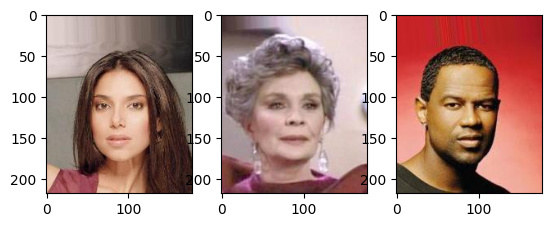

In [1]:
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall24/week09_generative/yfile.py -O yfile.py
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
  print("Downloading...") # this will download 1.4 gb file, downloading will take some time (8-10 minutes)
  download_from_yadisk(short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
                        filename=FILENAME, target_dir=TARGET_DIR)
  # alternative manual download:  https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW

  print("Extracting...")
  !unzip celeba.zip  # extract images; you don't need to run it every time
  print("Done!")
else:
  print("Found previously downloaded data!")

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
assert filesize > 2 ** 30, "{filesize} GiB is too small, something wrong with downloading - please clean up and re-download"

import matplotlib.pyplot as plt
plt.subplot(131); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/100019.jpg"))
plt.subplot(132); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/000084.jpg"))
plt.subplot(133); plt.imshow(plt.imread("celeba/celeba/img_align_celeba/148483.jpg"))

## Prepare the data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid
from tqdm import tqdm
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [3]:
# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment-out .Grayscale below :)


class CropCelebA64:  # custom preprocessing for CelebA
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic
    def __repr__(self):
        return self.__class__.__name__ + '()'


train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),

        torchvision.transforms.Grayscale()
    ]),
    #download=True,   # in case of problems with downloading from gdrive above
)

validation_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='valid',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.ToTensor(),

        torchvision.transforms.Grayscale()
    ]),
)

In [4]:
# Hold out the first 10k images for evaluation
num_images = 10000
real_images_tensor = torch.stack([train_dataset[i][0] for i in range(num_images)], dim=0)
real_images = real_images_tensor.data.numpy().transpose([0, 2, 3, 1])
np.savez("real.npz", Pictures=real_images.reshape(num_images, 64 * 64 * 1))

In [5]:
BATCH_SIZE = 64  # feel free to alter after initial tuning

# you may find useful parameters `num_workers` and `pin_memory`
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)
print("Image batch shape:", next(iter(train_loader))[0].shape)

Image batch shape: torch.Size([64, 1, 64, 64])


# Autoencoder

Why to use all this complicated formulaes and regularizations, what is the need for variational inference? To analyze the difference, let's first train just an autoencoder on the data:

In [6]:
dimZ = 100  # Considering face reconstruction task, which size of representation seems reasonable?

# Define the decoder and encoder as networks with one hidden fc-layer
# (that means you will have 2 fc layers in each net)
# Use ReLU for hidden layers' activations
# GlorotUniform initialization for W
# Zero initialization for biases
# It's also convenient to put sigmoid activation on output layer to get nice normalized pics


class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()



        self.encoder = nn.Sequential(nn.Linear(1*64*64, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, 2*dimZ))
        self.decoder = nn.Sequential(nn.Linear(dimZ, 256),
                                     nn.ReLU(),
                                     nn.Linear(256, 1*64*64),
                                     nn.Sigmoid())
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)

        hidden = self.encoder(x_flat)

        mu, log_sigma = hidden.chunk(2, dim=1)
        std = torch.exp(log_sigma)
        epsilon = torch.randn_like(std)
        latent_code = mu + std * epsilon
        reconstruction_flat = self.decoder(latent_code)

        reconstruction = reconstruction_flat.view(x.size(0), 1, 64, 64)

        return reconstruction, mu, log_sigma

In [7]:
# Create MSE loss function
criterion = torch.nn.MSELoss()

autoencoder = Autoencoder().to(device)

# Use Adam optimizer
optimizer = optim.Adam(autoencoder.parameters())

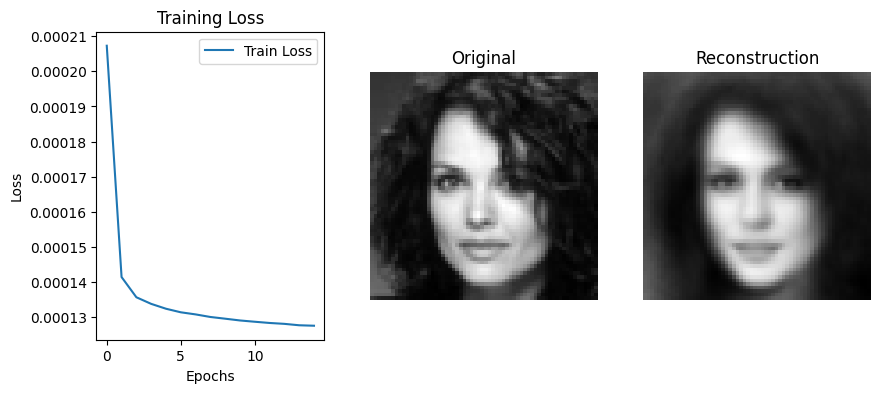

In [9]:
epochs = 15
train_loss_history = []

for epoch in range(epochs):
    autoencoder.train()
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in pbar:
        if isinstance(batch, list) or isinstance(batch, tuple):
            imgs = batch[0]
        else:
            imgs = batch

        imgs = imgs.to(device)

        optimizer.zero_grad()

        recon_imgs, mu, log_sigma = autoencoder(imgs)
        loss = criterion(recon_imgs, imgs)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item() / len(imgs)})

    avg_loss = epoch_loss / len(train_dataset)
    train_loss_history.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        clear_output(wait=True)
        autoencoder.eval()

        with torch.no_grad():
            val_batch = next(iter(val_loader))
            val_imgs = val_batch[0].to(device)
            val_recon, _, _ = autoencoder(val_imgs)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 3, 1)
        plt.plot(train_loss_history, label='Train Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training Loss')

        plt.subplot(1, 3, 2)
        plt.imshow(val_imgs[0].cpu().squeeze(), cmap='gray')
        plt.title('Original')
        plt.axis('off')


        plt.subplot(1, 3, 3)
        plt.imshow(val_recon[0].cpu().squeeze(), cmap='gray')
        plt.title('Reconstruction')
        plt.axis('off')

        plt.show()

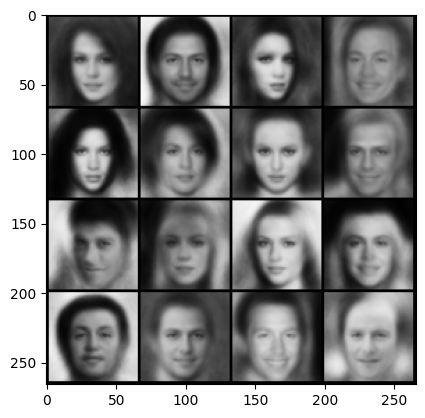

In [13]:
# Examine the reconstructions
from itertools import islice

images, _ = list(islice(val_loader, 1))[0]
reconstruction, mu, sigma = autoencoder(images.to(device))

reconstruction = reconstruction[:16].cpu()
plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

Reconstruction is not bad, right?  Okay, it very well might be bad, but it should at least be a blurry image.

# Sampling

Let's now sample several latent vectors and perform inference from $z$, reconstruct an image given some random $z$ representations.

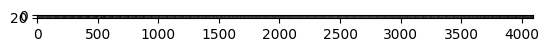

In [14]:
z = torch.randn(25, dimZ) * 0.5
reconstruction = autoencoder.decoder(z.to(device)).clamp(0, 1)

plt.imshow(make_grid(reconstruction.cpu(), nrow=5).permute(1, 2, 0))

So, if we sample $z$ from normal, whould we eventually generate all possible faces? What do you think?

# Variational Autoencoder

Bayesian approach in deep learning considers everything in terms of distributions. Now our encoder generates not just a vector $z$ but posterior ditribution $q(z|x)$. In our case distribution $q$ is Gaussian distibution $N(\mu, \sigma)$ with parameters $\mu$, $\sigma$. Technically, the first difference is that you need to split bottleneck layer in two. One dense layer will generate vector $\mu$, and another will generate vector $\sigma$. Reparametrization trick should be implemented using the **gaussian_sampler** layer, that generates random vetor $\epsilon$ and returns $\mu+\sigma\epsilon \sim N(\mu, \sigma)$ .

Since our decoder is also a function that generates distribution, we need to do the same splitting for output layer. When testing the model we will look only on mean values, so one of the output will be actual autoencoder output.

In this homework we only ask for implementation of the simplest version of VAE - one $z$ sample per input. You can consider to sample several outputs from one input and average them.

In [15]:
# to compare with conventional AE, keep these hyperparameters
# or change them for the values that you used before
dimZ = 100

# define the network
# you can start from https://github.com/pytorch/examples/blob/master/vae/main.py
# or Theano-based examples here https://github.com/Lasagne/Recipes/blob/master/examples/variational_autoencoder/variational_autoencoder.py
# and here https://github.com/y0ast/Variational-Autoencoder/blob/master/VAE.py
# but remember that this is not your ground truth since the data is not MNIST


class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.enc_h1 = nn.Linear(4096, 256)

        self.enc_mu = nn.Linear(256, dimZ)
        self.enc_logsigma = nn.Linear(256, dimZ)

        self.dec_h1 = nn.Linear(dimZ, 256)

        self.dec_mu = nn.Linear(256, 4096)
        self.dec_logsigma = nn.Linear(256, 4096)

        self.relu = nn.ReLU()

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(logsigma)
            epsilon = torch.randn_like(std)
            return mu + epsilon * std
        else:
            return mu

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)

        h_enc = self.relu(self.enc_h1(x_flat))
        mu_z = self.enc_mu(h_enc)
        logsigma_z = self.enc_logsigma(h_enc)

        z = self.gaussian_sampler(mu_z, logsigma_z)

        h_dec = self.relu(self.dec_h1(z))
        reconstruction_mu = torch.sigmoid(self.dec_mu(h_dec))
        reconstruction_logsigma = self.dec_logsigma(h_dec)

        return reconstruction_mu, reconstruction_logsigma, mu_z, logsigma_z

And the last, but not least! Place in the code where the most of the formulaes goes to - optimization objective. The objective for VAE has it's own name - variational lowerbound. And as for any lowerbound our intention is to maximize it. Here it is (for one sample $z$ per input $x$):

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z) \to max$$

Your next task is to implement two functions that compute KL-divergence and the second term - log-likelihood of an output. Here is some necessary math for your convenience:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$
$$\log p_{\theta}(x|z) = \sum_{i=1}^{dimX}\log p_{\theta}(x_i|z)=\sum_{i=1}^{dimX} \log \Big( \frac{1}{\sigma_i\sqrt{2\pi}}e^{-\frac{(\mu_i-x)^2}{2\sigma_i^2}} \Big)=...$$

Don't forget in the code that you are using $\log\sigma$ as variable. Explain, why not $\sigma$?

In [16]:
def KL_divergence(mu, logsigma):
    return -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma))

def log_likelihood(x, mu, logsigma):

    x_flat = x.view(x.size(0), -1)

    const_term = 0
    sigma_term = logsigma
    dist_term = (x_flat - mu).pow(2) / (2 * torch.exp(2 * logsigma))

    return -torch.sum(sigma_term + dist_term)


def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):

    LL = log_likelihood(x, mu_gen, logsigma_gen)
    KL = KL_divergence(mu_z, logsigma_z)

    return -LL + KL

And train the model:

In [17]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

epochs = 15
loss_history = []

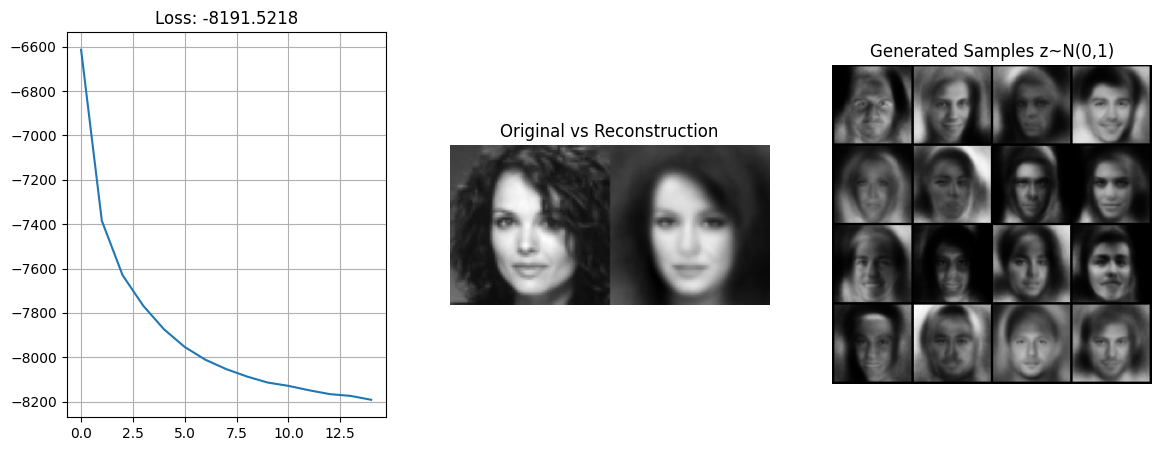

In [19]:
for epoch in range(epochs):
    vae.train()
    epoch_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        if isinstance(batch, list) or isinstance(batch, tuple):
            imgs = batch[0]
        else:
            imgs = batch
        imgs = imgs.to(device)

        optimizer.zero_grad()

        mu_gen, logsigma_gen, mu_z, logsigma_z = vae(imgs)

        loss = loss_vae(imgs, mu_gen, logsigma_gen, mu_z, logsigma_z)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1)

        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        clear_output(wait=True)
        vae.eval()

        with torch.no_grad():
            test_imgs = next(iter(val_loader))[0].to(device)
            recon_mu, _, _, _ = vae(test_imgs)

            z_sample = torch.randn(16, dimZ).to(device)
            h_dec = vae.relu(vae.dec_h1(z_sample))
            gen_mu = torch.sigmoid(vae.dec_mu(h_dec))

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 3, 1)
        plt.plot(loss_history)
        plt.title(f'Loss: {avg_loss:.4f}')
        plt.grid()

        plt.subplot(1, 3, 2)
        show_img = torch.cat([test_imgs[0], recon_mu[0].view(1, 64, 64)], dim=2)
        plt.imshow(show_img.cpu().squeeze(), cmap='gray')
        plt.title('Original vs Reconstruction')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        grid_img = np.transpose(torchvision.utils.make_grid(gen_mu.view(16, 1, 64, 64).cpu(), nrow=4).numpy(), (1, 2, 0))
        plt.imshow(grid_img)
        plt.title('Generated Samples z~N(0,1)')
        plt.axis('off')

        plt.show()

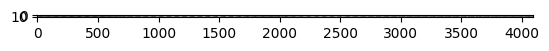

In [20]:
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = vae(images.to(device))
reconstruction = mu_gen[:16].cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

And finally sample from VAE.

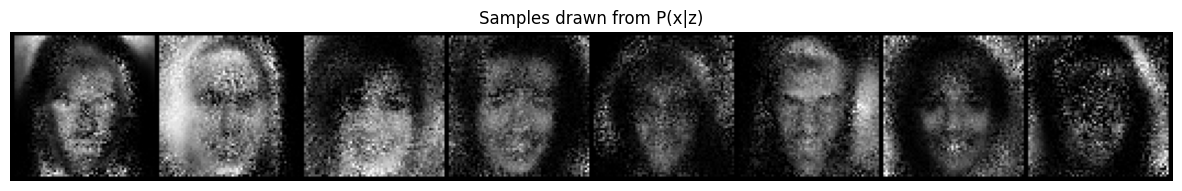

In [21]:
def sample_from_decoder_distribution(vae_model, n_samples=10):
    vae_model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, dimZ).to(device)

        h_dec = vae_model.relu(vae_model.dec_h1(z))
        mu_gen = torch.sigmoid(vae_model.dec_mu(h_dec))
        logsigma_gen = vae_model.dec_logsigma(h_dec)

        sigma_gen = torch.exp(logsigma_gen)
        epsilon = torch.randn_like(mu_gen)

        sampled_images = mu_gen + sigma_gen * epsilon
        sampled_images = torch.clamp(sampled_images, 0, 1)

        return sampled_images.view(n_samples, 1, 64, 64)

samples = sample_from_decoder_distribution(vae, n_samples=8)
plt.figure(figsize=(15, 3))
plt.imshow(np.transpose(torchvision.utils.make_grid(samples.cpu(), nrow=8).numpy(), (1, 2, 0)))
plt.title("Samples drawn from P(x|z)")
plt.axis('off')
plt.show()

Even if in practice you do not see the much difference between AE and VAE, or VAE is even worse, the little bayesian inside you should be jumping for joy right now.

In VAE you can truly sample from image distribution $p(x)$, while in AE there is no easy and correct way to do it.

# If you made it here - Congrats! (and here's an optional bonus task)

If you managed to tune your autoencoders to converge and learn something about the world, now it's time to make fun out of it. As you may have noticed, there are face attributes in dataset. We're interesting in "Smiling" column (index 31 of the attribute vector), but feel free to try others as well! Here is the first task:

1) Extract the "Smilling" attribute and create a two sets of images: 10 smiling faces and 10 non-smiling ones.

2) Compute latent representations for each image in "smiling" set and average those latent vectors. Do the same for "non-smiling" set. You have found **"vector representation"** of the "smile" and "no smile" attribute.

3) Compute the difference: "smile" vector minus "non-smile" vector.

3) Now check if **"feature arithmetics"** works. Sample a face without smile, encode it and add the diff from p. 3. Check if it works with both AE and VAE.